# Optimization Methods Comparison
**Authors:** Isabella Johnson & Mia Bella Rodriguez  

## Overview
This project implements and compares six numerical optimization algorithms on two test functions:
- **Quadratic function:** f(x,y) = x² + 10y²
- **Rosenbrock function:** f(x₁,x₂) = 100(x₂ - x₁²)² + (1 - x₁)²

## Setup
Import libraries and configure plot styling.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm, inv, eigvals

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [8, 6]
plt.rcParams['font.size'] = 12

## Part 1: Quadratic Function
### f(x,y) = x² + 10y²

This well-conditioned quadratic serves as the baseline test. Its elliptical contours
and known closed-form minimum at (0,0) make it ideal for comparing convergence behavior across methods.

In [ ]:
# Define the function and gradient

def f1(x):
    """Objective function: f(x,y) = x^2 + 10*y^2"""
    return x[0]**2 + 10*x[1]**2

def grad_f1(x):
    """Gradient of f(x,y) = x^2 + 10*y^2"""
    return np.array([2*x[0], 20*x[1]])

f(1,1) = 11.0
grad_f(1,1) = [ 2. 20.]


### Method 1: Constant Step Size
Gradient descent with a fixed step size α = 0.05. Simple but sensitive to the choice of step size —
too large diverges, too small is slow.

In [ ]:
# Constant step size function
x0 = np.array([5.0, 5.0])
step_size = 0.05

# Running gradient descent using new given function
def gradient_descent_constant(f, grad_f, x0, step_size, tol=1e-6, max_iter=1000):

    x = x0.copy().astype(float)
    x_history = [x.copy()]
    f_history = [f(x)]

    for k in range(max_iter):
        grad = grad_f(x)

        # Check stopping criterion
        if norm(grad) < tol:
            print(f"Converged in {k} iterations!")
            break

        # Gradient descent update
        x = x - step_size * grad

        # Store history
        x_history.append(x.copy())
        f_history.append(f(x))

    # Check if we reached maximum iterations without convergence
    if k == max_iter - 1: # Remember that k starts at 0, so we need to check for max_iter - 1
        print(f"Maximum iterations ({max_iter}) reached.")

    return x_history, f_history

# Run gradient descent
x0 = np.array([5.0, 5.0])  # Let x0 = (5,5)^T
step_size = 0.05           # Setting step size to 0.05

x_hist_constant, f_hist_constant = gradient_descent_constant(f1, grad_f1, x0, step_size)

# Print results
print(f"\nFinal point: ({x_hist_constant[-1][0]:.6f}, {x_hist_constant[-1][1]:.6f})")
print(f"Final function value: {f_hist_constant[-1]:.10f}")
print(f"Number of iterations: {len(f_hist_constant) - 1}")



Converged in 153 iterations!

Final point: (0.000000, 0.000000)
Final function value: 0.0000000000
Number of iterations: 153


### Method 2: Backtracking Line Search (Armijo Condition)
Adaptively shrinks the step size each iteration until the Armijo sufficient decrease condition is satisfied.
More robust than constant step size without requiring second-order information.

In [ ]:
# Backtracking line search

def backtracking_line_search(f, grad_f, x, alpha=0.3, beta=0.8):
    """
    Backtracking line search to find step size satisfying Armijo condition.

    Parameters:
    -----------
    f : function
        Objective function
    grad_f : function
        Gradient of objective function
    x : numpy array
        Current point
    alpha : float
        Armijo parameter (typically 0.1 to 0.4)
    beta : float
        Step size reduction factor (typically 0.5 to 0.9)

    Returns:
    --------
    t : float
        Step size satisfying Armijo condition
    """
    t = 1.0  # Initial step size

    grad = grad_f(x)

    # Backtracking loop, going through and changing t to beta*t
    while f(x - t * grad) > f(x) - alpha * t * np.linalg.norm(grad)**2:
        t = beta * t

    return t


In [ ]:
# Gradient descent with backtracking

def gradient_descent_backtracking(f, grad_f, x0, alpha=0.3, beta=0.8, tol=1e-6, max_iter=1000):
    """
    Gradient descent with backtracking line search.

    Parameters:
    -----------
    f : function
        Objective function
    grad_f : function
        Gradient of objective function
    x0 : numpy array
        Initial point
    alpha : float
        Armijo parameter
    beta : float
        Step size reduction factor
    tol : float
        Stopping tolerance
    max_iter : int
        Maximum iterations

    Returns:
    --------
    x_history : list
        List of iterates
    f_history : list
        List of function values
    """
    x = x0.copy().astype(float)
    x_history = [x.copy()]
    f_history = [f(x)]

    # Run gradient descent
    for k in range(max_iter):
        grad = grad_f(x)

        # Check stopping criterion
        if norm(grad) < tol:
            print(f"Converged in {k} iterations!")
            break

        # Obtain step size from backtracking
        step_size = backtracking_line_search(f, grad_f, x, alpha, beta)

        # Gradient descent backtracking update
        x = x - step_size * grad

        # Store history
        x_history.append(x.copy())
        f_history.append(f(x))

    # Check if we reached maximum iterations without convergence
    if k == max_iter - 1: # k starts at 0, so we need to check for max_iter - 1
        print(f"Maximum iterations ({max_iter}) reached.")

    return x_history, f_history

In [ ]:
# Run gradient descent with backtracking on f(x,y) = x^2 + 10*y^2

x0 = np.array([5.0, 5.0]) # Let x0 = (5,5)^T

# Calling backtracking method
x_hist_backtracking, f_hist_backtracking = gradient_descent_backtracking(f1, grad_f1, x0)

# Printing results
print(f"\nFinal point: ({x_hist_backtracking[-1][0]:.6f}, {x_hist_backtracking[-1][1]:.6f})")
print(f"Final function value: {f_hist_backtracking[-1]:.10f}")
print(f"Number of iterations: {len(f_hist_backtracking) - 1}")

Converged in 84 iterations!

Final point: (0.000000, 0.000000)
Final function value: 0.0000000000
Number of iterations: 84


### Method 3: Exact Line Search
For quadratic functions, the optimal step size has a closed form:

t* = ||∇f||² / (2 · ∇f^T Q ∇f)

This is only tractable for quadratics but gives the fastest gradient descent convergence on them.

In [ ]:
# Implement gradient descent with exact line search

def gradient_descent_exact(f, grad_f, Q, x0, tol=1e-6, max_iter=1000):
    """
    Gradient descent with exact line search for quadratic functions.

    Parameters:
    -----------
    f : function
        Objective function
    grad_f : function
        Gradient of objective function
    Q : numpy array
        Hessian matrix (for quadratic: f(x) = 0.5*x'Qx - b'x + c)
    x0 : numpy array
        Initial point
    tol : float
        Stopping tolerance
    max_iter : int
        Maximum iterations

    Returns:
    --------
    x_history : list
        List of iterates
    f_history : list
        List of function values
    """
    x = x0.copy().astype(float)
    x_history = [x.copy()]
    f_history = [f(x)]

    # Implement gradient descent with exact line search
    # Hint: t_optimal = ||grad||^2 / (2*(grad' @ Q @ grad))

    for k in range(max_iter):
        grad = grad_f(x)

        # Check stopping criterion
        if norm(grad) < tol:
            print(f"Converged in {k} iterations!")
            break

        # Calculate exact step size
        t_optimal = norm(grad)**2 / (2*grad@Q@grad)

        # Gradient descent backtracking update
        x = x - t_optimal * grad

        # Store history
        x_history.append(x.copy())
        f_history.append(f(x))

    # Check if we reached maximum iterations without convergence
    if k == max_iter - 1: # k starts at 0, so we need to check for max_iter - 1
        print(f"Maximum iterations ({max_iter}) reached.")
    return x_history, f_history

In [ ]:
# Apply to f(x,y) = x^2 + 10y^2

# Define the Hessian matrix Q
Q1 = np.array([[1, 0], [0, 10]])  # row reduced Hessian of f(x,y) = x^2 + 10y^2
x0 = np.array([5.0, 5.0]) # Initial x at 5.0, 5.0

# Run gradient descent with exact line search

# Calling exact line search descent method
x_hist_exact, f_hist_exact = gradient_descent_exact(f1, grad_f1, Q1, x0)

# Printing results
print(f"\nFinal point: ({x_hist_exact[-1][0]:.6f}, {x_hist_exact[-1][1]:.6f})")
print(f"Final function value: {f_hist_exact[-1]:.10f}")
print(f"Number of iterations: {len(f_hist_exact) - 1}")



Converged in 15 iterations!

Final point: (0.000000, -0.000000)
Final function value: 0.0000000000
Number of iterations: 15


### Method 4: Newton's Method
Uses second-order (Hessian) information to compute the search direction:

d = -H⁻¹ ∇f

For quadratic functions, Newton's method converges in a single step since the Hessian is constant.

In [ ]:
# Newton's Method Implementation

def newtons_method(f, grad_f, hess_f, x0, tol=1e-6, max_iter=100):
    """
    Newton's method for unconstrained optimization.

    Parameters:
    -----------
    f : function
        Objective function
    grad_f : function
        Gradient of objective function
    hess_f : function
        Hessian of objective function
    x0 : numpy array
        Initial point
    tol : float
        Stopping tolerance
    max_iter : int
        Maximum iterations

    Returns:
    --------
    x_history : list
        List of iterates
    f_history : list
        List of function values
    """
    x = x0.copy().astype(float)
    x_history = [x.copy()]
    f_history = [f(x)]

    for k in range(max_iter):
        grad = grad_f(x)

        # Check stopping criterion
        if norm(grad) < tol:
            print(f"Newton's method converged in {k} iterations!")
            break

        # Compute Hessian and Newton direction
        H = hess_f(x)

        # Newton step: solve H @ d = -grad
        try:
            d = np.linalg.solve(H, -grad)
        except np.linalg.LinAlgError:
            print("Hessian is singular!")
            break

        # Update
        x = x + d

        # Store history
        x_history.append(x.copy())
        f_history.append(f(x))

    if k == max_iter - 1:
        print(f"Maximum iterations ({max_iter}) reached.")

    return x_history, f_history

In [ ]:
# Apply Newton's Method to f(x,y) = x^2 + 10*y^2

# Implement the Hessian
def hess_f1(x):
    """Hessian of f(x,y) = x^2 + 10*y^2"""
    return np.array([[2,0],[0,20]])

# Run Newton's method

x0 = np.array([5.0, 5.0])

# Define f and grad_f
def f_newton(x):
  """function f(x,y) = x^2 + 10y^2"""
  return x[0]**2 + 10*x[1]**2

def grad_f_newton(x):
  """gradient of f(x,y) = x^2 + 10y^2"""
  return np.array([2*x[0],20*x[1]])

x_hist_newton_method, f_hist_newton_method = newtons_method(f_newton, grad_f_newton, hess_f1, x0)

print(f"\nFinal point: ({x_hist_newton_method[-1][0]:.6f}, {x_hist_newton_method[-1][1]:.6f})")
print(f"Final function value: {f_hist_newton_method[-1]:.10f}")
print(f"Number of iterations: {len(f_hist_newton_method) - 1}")

Newton's method converged in 1 iterations!

Final point: (0.000000, 0.000000)
Final function value: 0.0000000000
Number of iterations: 1


### Method 5: Gauss-Newton Method
Designed for nonlinear least squares problems of the form f(x) = ||F(x)||².
Approximates the Hessian using the Jacobian: H ≈ JᵀJ, avoiding expensive second derivative computation.

Update rule: x_{k+1} = x_k - (JᵀJ)⁻¹ Jᵀ F(x_k)

In [ ]:
# Implement Gauss Newton Method
def gauss_newtons_method(f, F, jacobian, x0, tol=1e-15, max_iter=1000):

    """
    Gauss Newton's method for nonlinear least squares optimization

    Parameters:
    -----------
    f : function
        Objective function
    F : function
        Residual vector function
    jacobian : function
        Jacobian matrix of f
    x0 : numpy array
        Initial point
    tol : float
        Stopping tolerance
    max_iter : int
        Maximum iterations

    Returns:
    --------
    x_history : list
        List of iterates
    f_history : list
        List of function values
    """
    x = x0.copy().astype(float)
    x_history = [x.copy()]
    f_history = [f(x)]

    for k in range(max_iter):

        # Define
        r = F(x)
        J = jacobian(x)
        grad = 2 * J.T @ r

        # Check if gradient is small enough
        if norm(grad) < tol:
            print(f"Gauss Newton's method converged in {k} iterations!")
            break

        # Compute Gauss Newton direction, d_k = (J(x_k)^T * J(x_k))^-1 *J(x_k)^T *F(x_k))
        try: d = np.linalg.solve(J.T @ J, J.T @ r)
        except np.linalg.LinAlgError:
            print("Hessian is singular!")
            break

        # Update
        x = x - d

        #Store history
        x_history.append(x.copy())
        f_history.append(f(x))

    if k == max_iter - 1:
        print(f"Maximum iterations ({max_iter}) reached.")

    return x_history, f_history


In [ ]:
# Define residual vector function and Jacobian matrix
# NOTE: F(x) = f1 - c1, f2 - c2, ..., fm(x) - cm. However, since we are minimizing to 0, c1 = c2 = ... = cm = 0.

# Residual vector function
def F(x):
  return np.array([
      x[0]**2,   # f1(x,y) - c1 = x^2 - 0
      10*x[1]**2 # f2(x,y) - c2 = 10y^2 - 0
      ])

# Jacobian matrix
def jacobian(x):
  return np.array([[2*x[0], 0], # Partial of x[0] and x[1] with respect to x[0]
                   [0, 20*x[1]] # Parial of x[0] and x[1] with respect to x[1]
                   ])


In [ ]:
# Run Gauss Newton's Method for f(x,y) = x^2 + 10*y^2

x0 = np.array([5.0, 5.0]) # Use same initial point as Newton's method
x_hist_gauss, f_hist_gauss = gauss_newtons_method(f1, F, jacobian, x0)

print(f"\nFinal point: ({x_hist_gauss[-1][0]:.6f}, {x_hist_gauss[-1][1]:.6f})")
print(f"Final function value: {f_hist_gauss[-1]:.10f}")
print(f"Number of iterations: {len(f_hist_gauss) - 1}")

Gauss Newton's method converged in 22 iterations!

Final point: (0.000001, 0.000001)
Final function value: 0.0000000000
Number of iterations: 22


### Method 6: Damped Gauss-Newton
Adds backtracking line search to the standard Gauss-Newton method for improved stability.
Particularly useful when the pure Gauss-Newton step is too aggressive near the solution.

In [ ]:
# Define damped gauss newton method

def damped_gauss_newton(f, F, jacobian, x0, alpha=0.3, beta=0.8, tol=1e-15, max_iter=1000):
    x = x0.copy().astype(float)
    x_history = [x.copy()]
    f_history = [f(x)]

    for k in range(max_iter):
        r = F(x)
        J = jacobian(x)

        # Step (a): compute d_k = (J^T J)^{-1} J^T F(x_k)
        try:
            d = np.linalg.solve(J.T @ J, J.T @ r)
        except np.linalg.LinAlgError:
            print("J^T J is singular!")
            break

        # Step (b): backtracking line search on h(t) = f(x_k - t*d_k)
        t = 1.0
        while f(x - t * d) > f(x) - alpha * t * np.linalg.norm(d)**2:
            t *= beta
            if t < 1e-16:
                break

        # Step (c): x_{k+1} = x_k - t_k * d_k
        x = x - t * d
        x_history.append(x.copy())
        f_history.append(f(x))

        # Step (d): stopping criterion on gradient of f at new point
        r_new = F(x)
        J_new = jacobian(x)
        grad_new = 2 * J_new.T @ r_new
        if np.linalg.norm(grad_new) <= tol:
            print(f"Damped Gauss-Newton converged in {k+1} iterations!")
            break

        if k == max_iter - 1:
            print(f"Maximum iterations ({max_iter}) reached.")

    return x_history, f_history

In [ ]:
# Run Damped Gauss-Newton on f(x,y) = x^2 + 10y^2

# Defining original residual and Jacobian
def F(x):
    return np.array([
        x[0]**2,
        10*x[1]**2
    ])

def jacobian(x):
    return np.array([
        [2*x[0], 0],
        [0, 20*x[1]]
    ])

x0 = np.array([5.0, 5.0]) # Keep same initial point

x_hist_damped_gauss, f_hist_damped_gauss = damped_gauss_newton(f1, F, jacobian, x0)

print(f"\nFinal point:          ({x_hist_damped_gauss[-1][0]:.6f}, {x_hist_damped_gauss[-1][1]:.6f})")
print(f"Final function value:  {f_hist_damped_gauss[-1]:.10f}")
print(f"Number of iterations:  {len(f_hist_damped_gauss) - 1}")

Damped Gauss-Newton converged in 22 iterations!

Final point:          (0.000001, 0.000001)
Final function value:  0.0000000000
Number of iterations:  22


### Part 1 Results: Convergence Comparison
The plot below shows function value vs. iteration count on a log scale for all six methods
applied to the quadratic function.

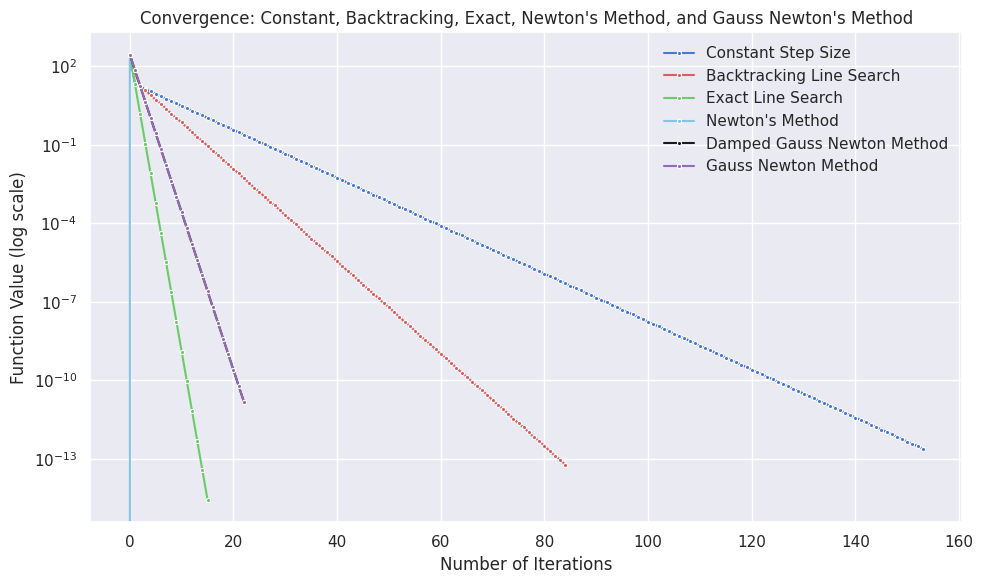

In [ ]:
# Create convergence graph
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

sns.set_theme(style="darkgrid", palette="muted")

fig, ax = plt.subplots(figsize=(10, 6))

methods = {
    'Constant Step Size':       (f_hist_constant,         'b'),
    'Backtracking Line Search': (f_hist_backtracking,     'r'),
    'Exact Line Search':        (f_hist_exact,            'g'),
    "Newton's Method":          (f_hist_newton_method,    'c'),
    'Damped Gauss Newton Method': (f_hist_damped_gauss,   'k'),
    'Gauss Newton Method':      (f_hist_gauss,            'm')
}

for label, (data, color) in methods.items():
    iters = np.arange(len(data))
    sns.lineplot(x=iters, y=data, ax=ax, label=label, color=color,
                 marker='o', markersize=3, linewidth=1.5)

ax.set_yscale('log')
ax.set_xlabel('Number of Iterations', fontsize=12)
ax.set_ylabel('Function Value (log scale)', fontsize=12)
ax.set_title("Convergence: Constant, Backtracking, Exact, Newton's Method, and Gauss Newton's Method",
             fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

### Key Observations — Quadratic Function
- **Newton's method** converges in **1 iteration** (exact for quadratics)
- **Exact line search** converges in **15 iterations**
- **Backtracking** converges in **84 iterations**
- **Constant step size** requires **153 iterations**
- **Gauss-Newton** converges in 22 iterations but stalls slightly near the solution — the JᵀJ Hessian approximation becomes less accurate as residuals become nonlinear near the minimum

### Contour Plots — Quadratic Function
Each subplot shows the optimization path overlaid on the contour map of f(x,y) = x² + 10y².
Black square = start point, white circle = final point.

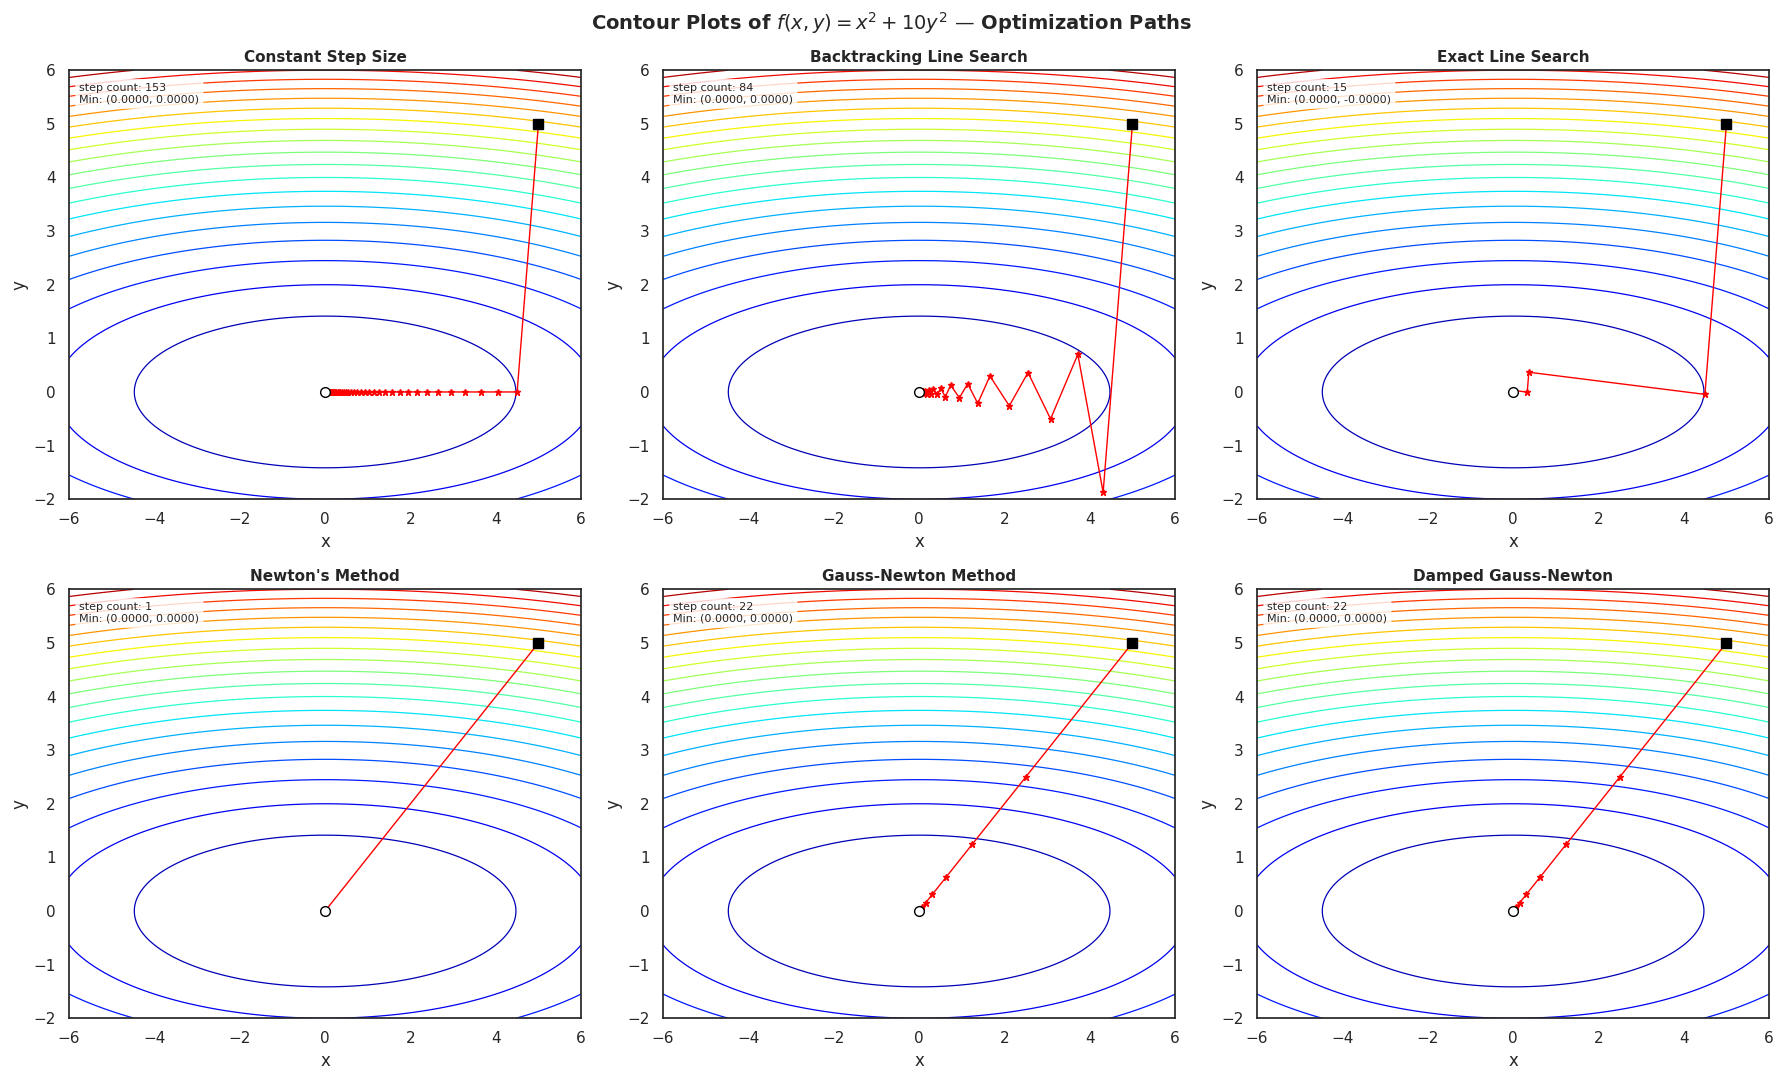

In [ ]:
# --- Contour grid ---
x_range = np.linspace(-6, 6, 400)
y_range = np.linspace(-2, 6, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = X**2 + 10*Y**2

# --- Plot ---
sns.set_theme(style='white')
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

methods = [
    ('Constant Step Size',       x_hist_constant,       'red'),
    ('Backtracking Line Search', x_hist_backtracking,   'red'),
    ('Exact Line Search',        x_hist_exact,          'red'),
    ("Newton's Method",          x_hist_newton_method,  'red'),
    ('Gauss-Newton Method',      x_hist_gauss,          'red'),
    ('Damped Gauss-Newton',      x_hist_damped_gauss,   'red'),
]

for ax, (title, x_hist, color) in zip(axes, methods):
    # Contour lines with heat colormap (blue=low, red/yellow=high)
    cs = ax.contour(X, Y, Z, levels=25, cmap='jet', linewidths=0.9)

    # Optimization path with asterisk markers
    path = np.array(x_hist)
    ax.plot(path[:, 0], path[:, 1], '-', color=color, linewidth=1.0)
    ax.plot(path[:, 0], path[:, 1], '*', color=color, markersize=5)

    # Start and end markers
    ax.plot(*path[0],  's', color='black', markersize=7, zorder=5)
    ax.plot(*path[-1], 'o', color='black', markersize=7, zorder=5, markerfacecolor='white')

    ax.set_xlim(-6, 6)
    ax.set_ylim(-2, 6)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

    # Info box
    n_steps = len(x_hist) - 1
    final = path[-1]
    info = f'step count: {n_steps}\nMin: ({final[0]:.4f}, {final[1]:.4f})'
    ax.text(0.02, 0.97, info, transform=ax.transAxes, fontsize=8,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle("Contour Plots of $f(x,y) = x^2 + 10y^2$ — Optimization Paths",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 2: Rosenbrock Function
### f(x₁,x₂) = 100(x₂ - x₁²)² + (1 - x₁)²

The Rosenbrock is a classic ill-conditioned benchmark. Its minimum is at (1,1) inside a narrow,
curved valley — easy to find the valley, hard to converge along it. Exact line search is excluded
here; constant step size is used in its place.

In [ ]:
# Implement the Rosenbrock-like function

def f_rosenbrock(x):
    """Rosenbrock-like function: f(x1,x2) = 100(x2 - x1^2)^2 + (1 - x1)^2"""
    return 100*((x[1] - x[0]**2)**2) + (1-x[0])**2

def grad_f_rosenbrock(x):
    """Gradient of Rosenbrock-like function"""
    return np.array([-400*x[0]*(x[1]-x[0]**2)-2*(1-x[0]), 200*(x[1]-x[0]**2)])

In [ ]:
# Define x0 and change max iterations
x0_ros = np.array([-1.0, 1.0])
max_iter_ros = 10000

step_size = 0.001  # Setting step size to 0.001

# Calling constant step size
x_ros_constant, f_ros_constant = gradient_descent_constant(f_rosenbrock, grad_f_rosenbrock, x0_ros, step_size, max_iter=max_iter_ros)

# Print results
print(f"\nFinal point using constant gradient descent: ({x_ros_constant[-1][0]:.6f}, {x_ros_constant[-1][1]:.6f})")
print(f"Final function value: {f_ros_constant[-1]:.10f}")
print(f"Number of iterations: {len(f_ros_constant) - 1}")

Maximum iterations (10000) reached.

Final point using constant gradient descent: (0.992482, 0.984990)
Final function value: 0.0000566157
Number of iterations: 10000


In [ ]:
# Calling backtracking method
x_ros_backtracking, f_ros_backtracking = gradient_descent_backtracking(f_rosenbrock, grad_f_rosenbrock, x0_ros, max_iter=max_iter_ros)

print(f"\nFinal point using backtracking: ({x_ros_backtracking[-1][0]:.6f}, {x_ros_backtracking[-1][1]:.6f})")
print(f"Final function value: {f_ros_backtracking[-1]:.10f}")
print(f"Number of iterations: {len(f_ros_backtracking) - 1}")

Maximum iterations (10000) reached.

Final point using backtracking: (1.000003, 1.000005)
Final function value: 0.0000000000
Number of iterations: 10000


In [ ]:
# Creating the Hessian of the Rosenbrock for Newton's method
def hess_f_rosenbrock(x):
    """
    Hessian of Rosenbrock-like function: f(x1,x2) = 100(x2 - x1^2)^2 + (1 - x1)^2

    """
    x1, x2 = x[0], x[1]

    return np.array([[1200*x[0]**2 - 400*x[1]+2,
                      -400*x[0]],
                       [-400*x[0],
                        200]])

In [ ]:
# Calling Newton's Method
x_hist_rosenbrock, f_hist_rosenbrock = newtons_method(f_rosenbrock, grad_f_rosenbrock, hess_f_rosenbrock, x0_ros)

print(f"\nFinal point: ({x_hist_rosenbrock[-1][0]:.6f}, {x_hist_rosenbrock[-1][1]:.6f})")
print(f"Final function value: {f_hist_rosenbrock[-1]:.10f}")
print(f"Number of iterations: {len(f_hist_rosenbrock) - 1}")


Newton's method converged in 2 iterations!

Final point: (1.000000, 1.000000)
Final function value: 0.0000000000
Number of iterations: 2


In [ ]:
# --- Rosenbrock Function Setup ---

def rosenbrock(x):
    """f(x1, x2) = 100*(x2 - x1^2)^2 + (1 - x1)^2"""
    return 100*(x[1] - x[0]**2)**2 + (1 - x[0])**2

def grad_rosenbrock(x):
    """Gradient of Rosenbrock"""
    dfdx1 = -400*x[0]*(x[1] - x[0]**2) - 2*(1 - x[0])
    dfdx2 =  200*(x[1] - x[0]**2)
    return np.array([dfdx1, dfdx2])

# Residuals: F(x) such that f(x) = ||F(x)||^2
def F_rosenbrock(x):
    """Residual vector for Rosenbrock"""
    return np.array([
        10*(x[1] - x[0]**2),   # F1: so F1^2 = 100*(x2-x1^2)^2
        (1 - x[0])              # F2: so F2^2 = (1-x1)^2
    ])

def jacobian_rosenbrock(x):
    """Jacobian of F_rosenbrock"""
    return np.array([
        [-20*x[0],  10],   # partial of F1(x1, x2)
        [-1,         0]    # partial of F2(x1, x2)
    ])

# Test
x_test = np.array([1.0, 1.0])
print(f"f(1,1)    = {rosenbrock(x_test)}")        # Should be 0
print(f"grad(1,1) = {grad_rosenbrock(x_test)}")   # Should be [0, 0]
print(f"F(1,1)    = {F_rosenbrock(x_test)}")       # Should be [0, 0]

f(1,1)    = 0.0
grad(1,1) = [-0.  0.]
F(1,1)    = [0. 0.]


In [ ]:
# Gauss Newton's Method on Roesenbrock

x0 = np.array([-1.0, 1.0])  # Using the same starting point

x_hist_gauss_ros, f_hist_gauss_ros = gauss_newtons_method(
    rosenbrock, F_rosenbrock, jacobian_rosenbrock, x0
)

print(f"\nFinal point:          ({x_hist_gauss_ros[-1][0]:.6f}, {x_hist_gauss_ros[-1][1]:.6f})")
print(f"Final function value:  {f_hist_gauss_ros[-1]:.10f}")
print(f"Number of iterations:  {len(f_hist_gauss_ros) - 1}")


Gauss Newton's method converged in 3 iterations!

Final point:          (1.000000, 1.000000)
Final function value:  0.0000000000
Number of iterations:  3


In [ ]:
# Damped Gauss-Newton on Rosenbrock

x0 = np.array([-1.0, 1.0]) # Still using same starting point

x_hist_damped_ros, f_hist_damped_ros = damped_gauss_newton(
    rosenbrock, F_rosenbrock, jacobian_rosenbrock, x0
)

print(f"\nFinal point:          ({x_hist_damped_ros[-1][0]:.6f}, {x_hist_damped_ros[-1][1]:.6f})")
print(f"Final function value:  {f_hist_damped_ros[-1]:.10f}")
print(f"Number of iterations:  {len(f_hist_damped_ros) - 1}")

Damped Gauss-Newton converged in 13 iterations!

Final point:          (1.000000, 1.000000)
Final function value:  0.0000000000
Number of iterations:  13


### Part 2 Results: Convergence Comparison

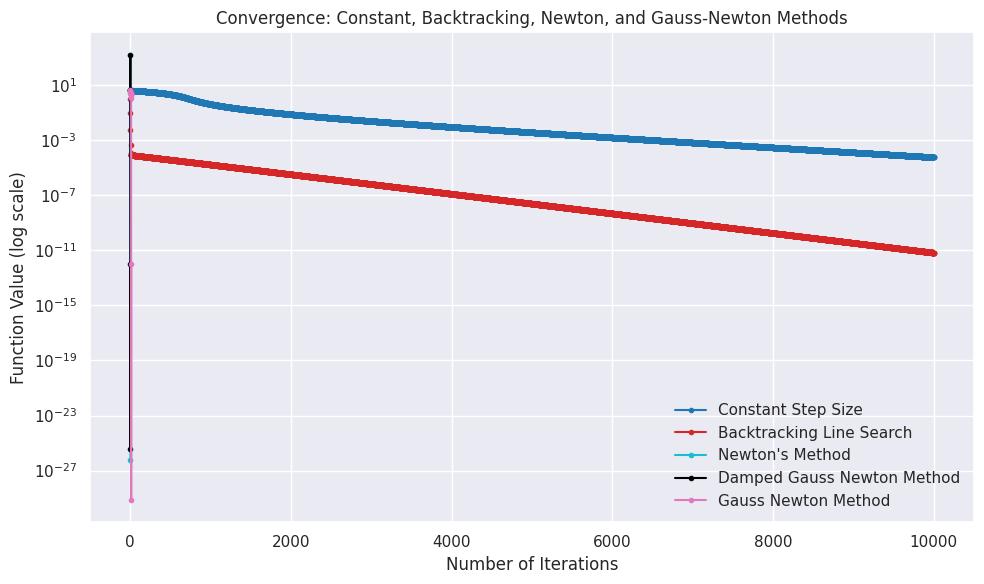

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style (no palette to avoid overrides)
sns.set_theme(style="darkgrid")

# Make data safe for log scale
def safe_log_data(arr):
    arr = np.array(arr, dtype=float)
    arr = np.nan_to_num(arr, nan=1e-12, posinf=1e12, neginf=1e-12)
    arr[arr <= 0] = 1e-12  # log scale requires positive values
    return arr

# Data
methods = {
    'Constant Step Size':       (safe_log_data(f_ros_constant),        '#1f77b4'),
    'Backtracking Line Search': (safe_log_data(f_ros_backtracking),    '#d62728'),
    "Newton's Method":          (safe_log_data(f_hist_rosenbrock),     '#17becf'),
    'Damped Gauss Newton Method': (safe_log_data(f_hist_gauss_ros),    '#000000'),
    'Gauss Newton Method':      (safe_log_data(f_hist_damped_ros),     '#e377c2')
}

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for label, (data, color) in methods.items():
    if len(data) == 0:
        print(f"Warning: {label} is empty, skipping.")
        continue

    iters = np.arange(len(data))

    ax.plot(
        iters,
        data,
        label=label,
        color=color,
        marker='o',
        markersize=3,
        linewidth=1.5
    )

# Axes formatting
ax.set_yscale('log')
ax.set_xlabel('Number of Iterations', fontsize=12)
ax.set_ylabel('Function Value (log scale)', fontsize=12)
ax.set_title(
    "Convergence: Constant, Backtracking, Newton, and Gauss-Newton Methods",
    fontsize=12
)

ax.legend()
plt.tight_layout()
plt.show()

### Key Observations — Rosenbrock Function
- **Gauss-Newton** converges in just **3 iterations** — the structured residual form F(x) makes it highly effective here
- **Damped Gauss-Newton** converges in **13 iterations** — slightly more due to the line search overhead, but more stable
- **Newton's method** converges in **2 iterations** using the exact Hessian
- **Backtracking and constant step size** both hit the 10,000 iteration limit, illustrating how poorly first-order methods handle ill-conditioned problems

### Contour Plots — Rosenbrock Function
The banana-shaped contours illustrate why first-order methods struggle: gradient directions point
away from the curved valley, causing slow zigzagging progress toward (1,1).

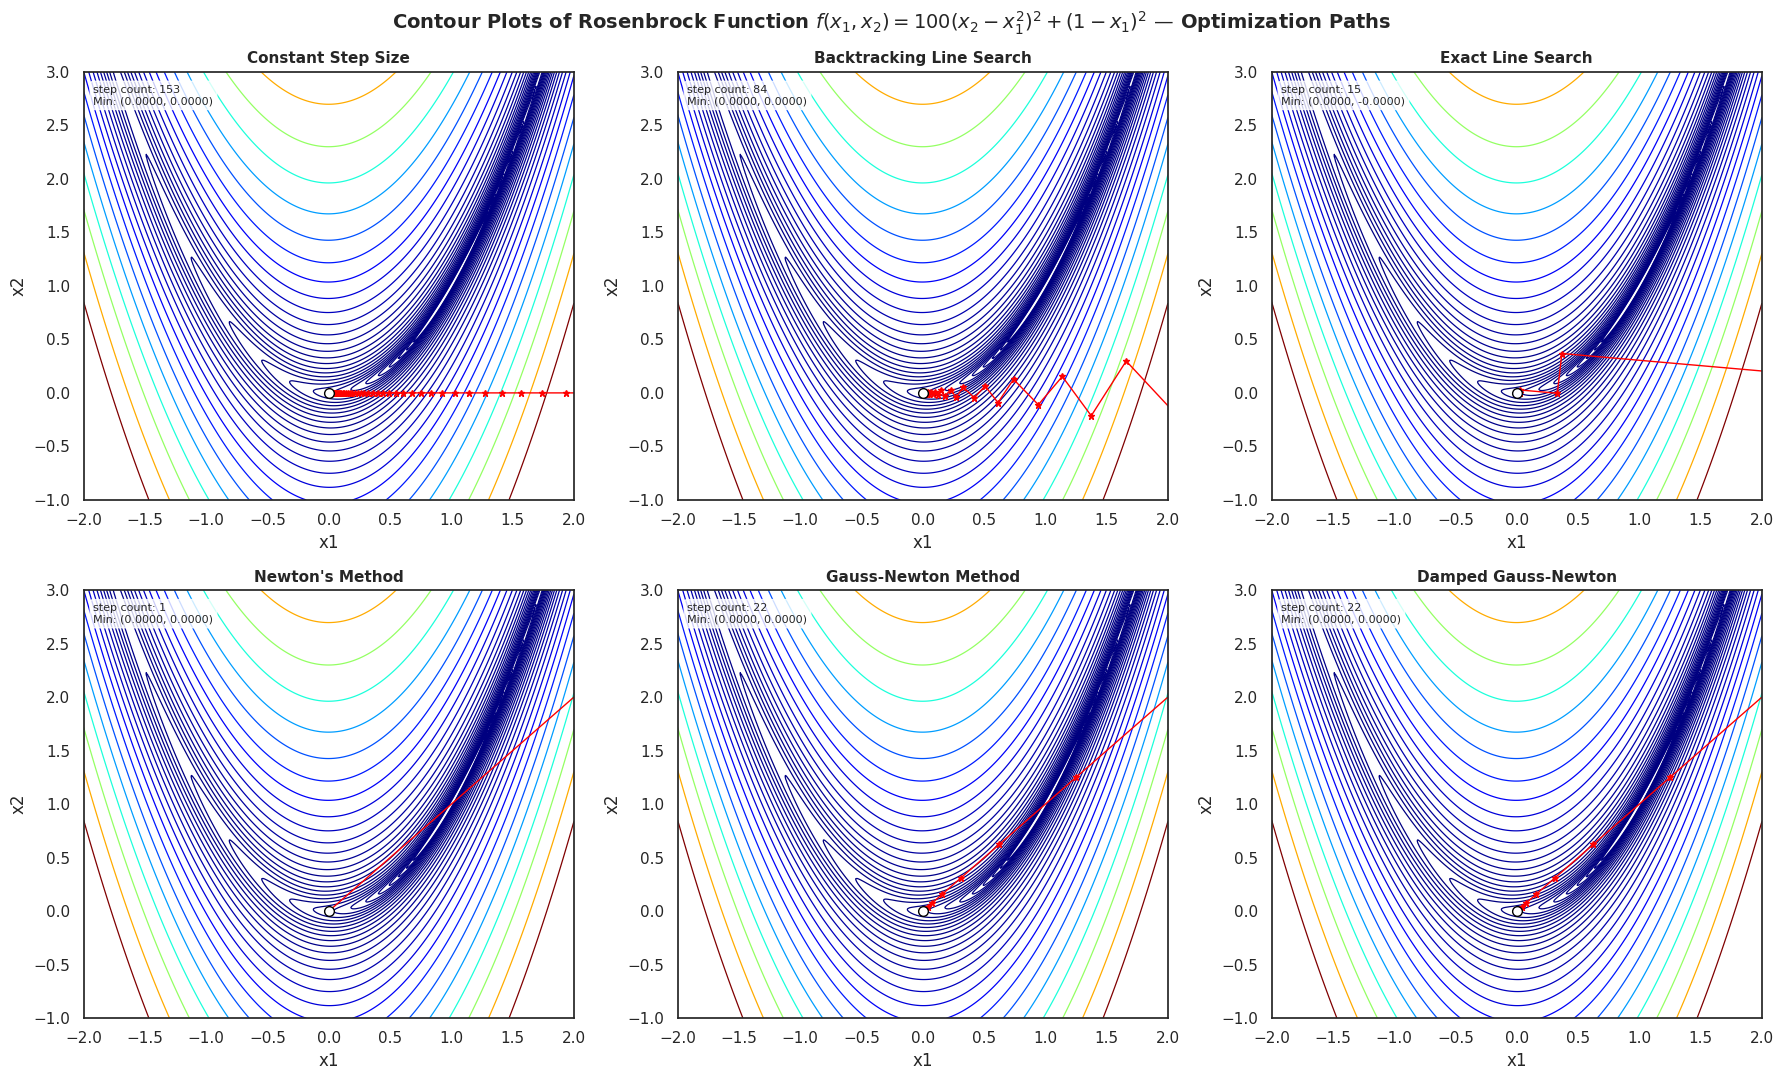

In [ ]:
# Contour plots import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Rosenbrock function ---
def rosenbrock(x1, x2):
    return 100*(x2 - x1**2)**2 + (1 - x1)**2

# --- Contour grid (adjusted for Rosenbrock shape) ---
x_range = np.linspace(-2, 2, 400)
y_range = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = rosenbrock(X, Y)

# --- Plot ---
sns.set_theme(style='white')
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

methods = [
    ('Constant Step Size',       x_hist_constant,       'red'),
    ('Backtracking Line Search', x_hist_backtracking,   'red'),
    ('Exact Line Search',        x_hist_exact,          'red'),
    ("Newton's Method",          x_hist_newton_method,  'red'),
    ('Gauss-Newton Method',      x_hist_gauss,          'red'),
    ('Damped Gauss-Newton',      x_hist_damped_gauss,   'red'),
]

for ax, (title, x_hist, color) in zip(axes, methods):
    # Contours (log spacing helps a LOT for Rosenbrock)
    levels = np.logspace(-1, 3, 30)
    cs = ax.contour(X, Y, Z, levels=levels, cmap='jet', linewidths=0.9)
    ax.set_yscale('linear')  # keep axes linear (important)

    # Optimization path
    path = np.array(x_hist)
    ax.plot(path[:, 0], path[:, 1], '-', color=color, linewidth=1.0)
    ax.plot(path[:, 0], path[:, 1], '*', color=color, markersize=5)

    # Start and end points
    ax.plot(*path[0],  's', color='black', markersize=7, zorder=5)
    ax.plot(*path[-1], 'o', color='black', markersize=7,
            markerfacecolor='white', zorder=5)

    # Axes formatting
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1, 3)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')

    # Info box
    n_steps = len(x_hist) - 1
    final = path[-1]
    info = f'step count: {n_steps}\nMin: ({final[0]:.4f}, {final[1]:.4f})'
    ax.text(0.02, 0.97, info, transform=ax.transAxes, fontsize=8,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Title
plt.suptitle(
    "Contour Plots of Rosenbrock Function $f(x_1,x_2)=100(x_2-x_1^2)^2+(1-x_1)^2$ — Optimization Paths",
    fontsize=14, fontweight='bold'
)

plt.tight_layout()
plt.show()

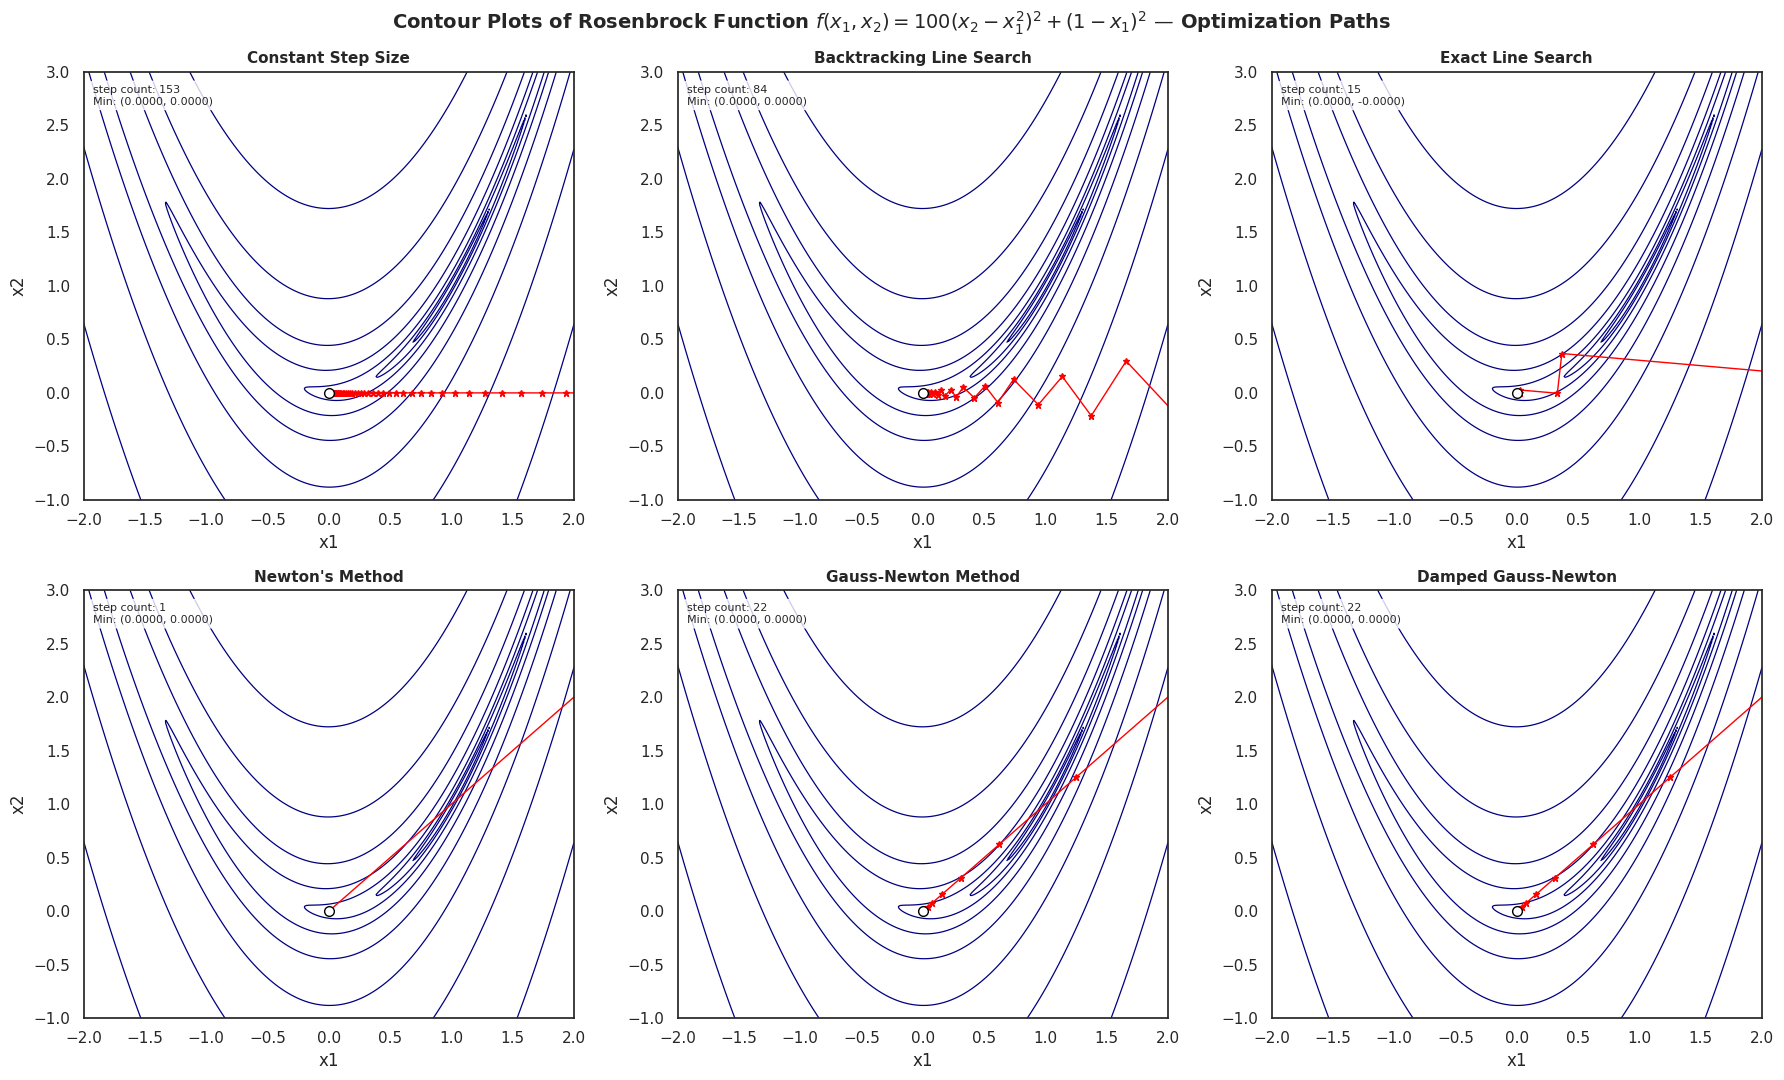

In [ ]:
# Contour plots for Rosenbrock zoomed in for better readability

# Rosenbrock function
def rosenbrock(x1, x2):
    return 100*(x2 - x1**2)**2 + (1 - x1)**2

# Contour grid (adjusted for Rosenbrock shape)
x_range = np.linspace(-2, 2, 400)
y_range = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = rosenbrock(X, Y)

# Plot
sns.set_theme(style='white')
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

methods = [
    ('Constant Step Size',       x_hist_constant,       'red'),
    ('Backtracking Line Search', x_hist_backtracking,   'red'),
    ('Exact Line Search',        x_hist_exact,          'red'),
    ("Newton's Method",          x_hist_newton_method,  'red'),
    ('Gauss-Newton Method',      x_hist_gauss,          'red'),
    ('Damped Gauss-Newton',      x_hist_damped_gauss,   'red'),
]

for ax, (title, x_hist, color) in zip(axes, methods):
    # Contours (log spacing helps a LOT for Rosenbrock)
    levels = np.logspace(-1, 10, 20)
    cs = ax.contour(X, Y, Z, levels=levels, cmap='jet', linewidths=0.9)
    ax.set_yscale('linear')  # keep axes linear (important)

    # Optimization path
    path = np.array(x_hist)
    ax.plot(path[:, 0], path[:, 1], '-', color=color, linewidth=1.0)
    ax.plot(path[:, 0], path[:, 1], '*', color=color, markersize=5)

    # Start and end points
    ax.plot(*path[0],  's', color='black', markersize=7, zorder=5)
    ax.plot(*path[-1], 'o', color='black', markersize=7,
            markerfacecolor='white', zorder=5)

    # Axes formatting
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1, 3)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')

    # Info box
    n_steps = len(x_hist) - 1
    final = path[-1]
    info = f'step count: {n_steps}\nMin: ({final[0]:.4f}, {final[1]:.4f})'
    ax.text(0.02, 0.97, info, transform=ax.transAxes, fontsize=8,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Title
plt.suptitle(
    "Contour Plots of Rosenbrock Function $f(x_1,x_2)=100(x_2-x_1^2)^2+(1-x_1)^2$ — Optimization Paths",
    fontsize=14, fontweight='bold'
)

plt.tight_layout()
plt.show()